In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import IsolationForest


# Load dataset
df = pd.read_csv("../data/Data.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nFirst 5 rows:")
print(df.head())

Shape: (377719, 7)

Columns:
['time', 'Cyclone_Inlet_Gas_Temp', 'Cyclone_Material_Temp', 'Cyclone_Outlet_Gas_draft', 'Cyclone_cone_draft', 'Cyclone_Gas_Outlet_Temp', 'Cyclone_Inlet_Draft']

Data types:
time                        object
Cyclone_Inlet_Gas_Temp      object
Cyclone_Material_Temp       object
Cyclone_Outlet_Gas_draft    object
Cyclone_cone_draft          object
Cyclone_Gas_Outlet_Temp     object
Cyclone_Inlet_Draft         object
dtype: object

Missing values:
time                        0
Cyclone_Inlet_Gas_Temp      0
Cyclone_Material_Temp       0
Cyclone_Outlet_Gas_draft    0
Cyclone_cone_draft          0
Cyclone_Gas_Outlet_Temp     0
Cyclone_Inlet_Draft         0
dtype: int64

First 5 rows:
               time Cyclone_Inlet_Gas_Temp Cyclone_Material_Temp  \
0  01-01-2017 00:00                 867.63                910.42   
1  01-01-2017 00:05                 879.23                918.14   
2  01-01-2017 00:10                 875.67                924.18   
3  01-01-201

In [5]:
# Convert time to datetime
df["time"] = pd.to_datetime(df["time"], format="mixed")

# Sensor columns
sensor_cols = [
    "Cyclone_Inlet_Gas_Temp",
    "Cyclone_Material_Temp",
    "Cyclone_Outlet_Gas_draft",
    "Cyclone_cone_draft",
    "Cyclone_Gas_Outlet_Temp",
    "Cyclone_Inlet_Draft"
]

# Convert sensor columns to numeric
for col in sensor_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Check missing values after conversion
print("Missing values after conversion:")
print(df.isnull().sum())

# Sort by time
df = df.sort_values("time").reset_index(drop=True)

print("\nTime range:")
print(df["time"].min(), "to", df["time"].max())

print("\nData types:")
print(df.dtypes)

Missing values after conversion:
time                           0
Cyclone_Inlet_Gas_Temp      1320
Cyclone_Material_Temp       1591
Cyclone_Outlet_Gas_draft    1321
Cyclone_cone_draft          1320
Cyclone_Gas_Outlet_Temp     1321
Cyclone_Inlet_Draft         1322
dtype: int64

Time range:
2017-01-01 00:00:00 to 2020-08-07 12:15:00

Data types:
time                        datetime64[ns]
Cyclone_Inlet_Gas_Temp             float64
Cyclone_Material_Temp              float64
Cyclone_Outlet_Gas_draft           float64
Cyclone_cone_draft                 float64
Cyclone_Gas_Outlet_Temp            float64
Cyclone_Inlet_Draft                float64
dtype: object


In [6]:
# Interpolate missing sensor values using time
df = df.set_index("time")

df[sensor_cols] = df[sensor_cols].interpolate(method="time")

# Check remaining missing values
print("Remaining missing values:")
print(df.isnull().sum())

# Restore time as a column
df = df.reset_index()

Remaining missing values:
Cyclone_Inlet_Gas_Temp      0
Cyclone_Material_Temp       0
Cyclone_Outlet_Gas_draft    0
Cyclone_cone_draft          0
Cyclone_Gas_Outlet_Temp     0
Cyclone_Inlet_Draft         0
dtype: int64


In [7]:
print(df.shape)
print(df.head())

(377719, 7)
                 time  Cyclone_Inlet_Gas_Temp  Cyclone_Material_Temp  \
0 2017-01-01 00:00:00                  867.63                 910.42   
1 2017-01-01 00:05:00                  879.23                 918.14   
2 2017-01-01 00:10:00                  875.67                 924.18   
3 2017-01-01 00:15:00                  875.28                 923.15   
4 2017-01-01 00:20:00                  891.66                 934.26   

   Cyclone_Outlet_Gas_draft  Cyclone_cone_draft  Cyclone_Gas_Outlet_Temp  \
0                   -189.54             -186.04                   852.13   
1                   -184.33             -182.10                   862.53   
2                   -181.26             -166.47                   866.06   
3                   -179.15             -174.83                   865.85   
4                   -178.32             -173.72                   876.06   

   Cyclone_Inlet_Draft  
0              -145.90  
1              -149.76  
2              -145.01 

In [8]:
print(df[sensor_cols].describe())

       Cyclone_Inlet_Gas_Temp  Cyclone_Material_Temp  \
count           377719.000000          377719.000000   
mean               726.025533             749.403034   
std                329.747766             352.074936   
min                  0.000000            -185.000000   
25%                855.880000             867.070000   
50%                882.320000             913.230000   
75%                901.080000             943.580000   
max               1157.630000            1375.000000   

       Cyclone_Outlet_Gas_draft  Cyclone_cone_draft  Cyclone_Gas_Outlet_Temp  \
count             377719.000000       377719.000000            377719.000000   
mean                -177.451478         -164.249238               714.456558   
std                   99.383821           90.310021               326.387912   
min                 -456.660000         -459.310000                13.790000   
25%                 -247.150000         -226.730000               799.095000   
50%            

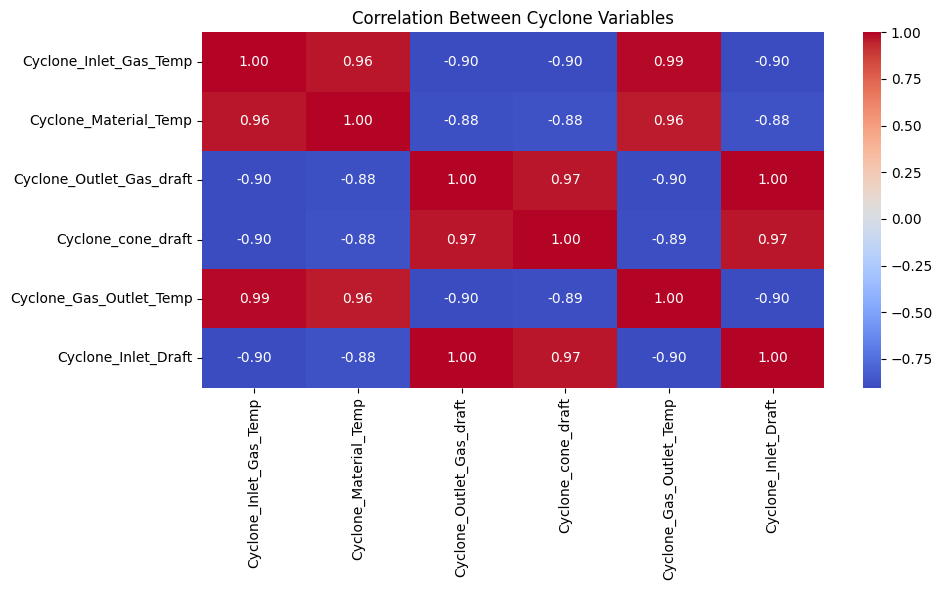

In [9]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[sensor_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Cyclone Variables")
plt.tight_layout()
plt.show()

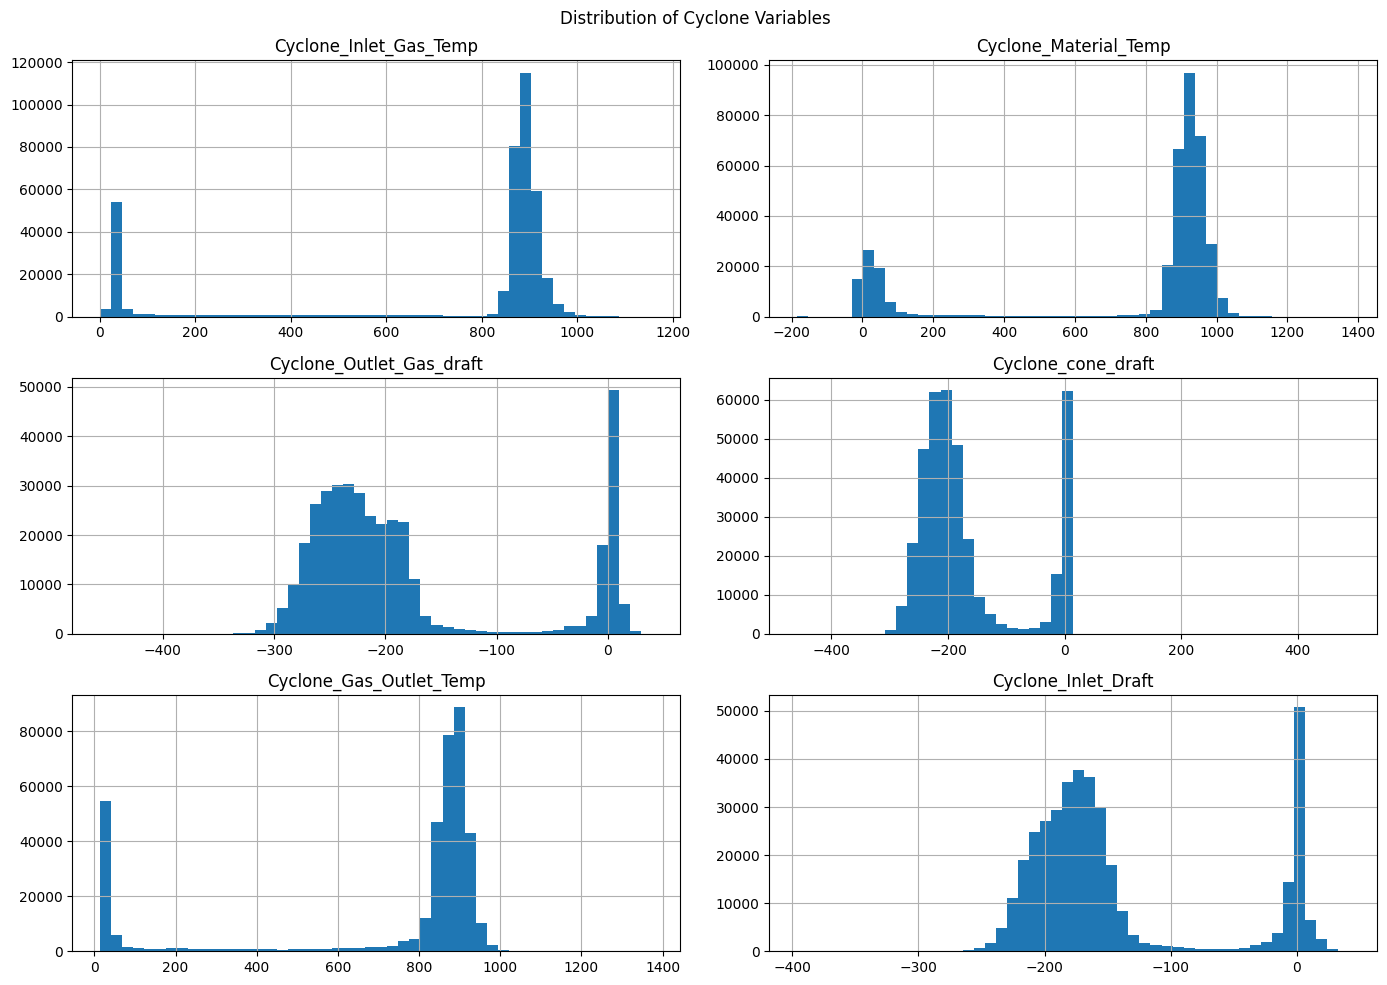

In [10]:
df[sensor_cols].hist(figsize=(14, 10), bins=50)
plt.suptitle("Distribution of Cyclone Variables")
plt.tight_layout()
plt.show()

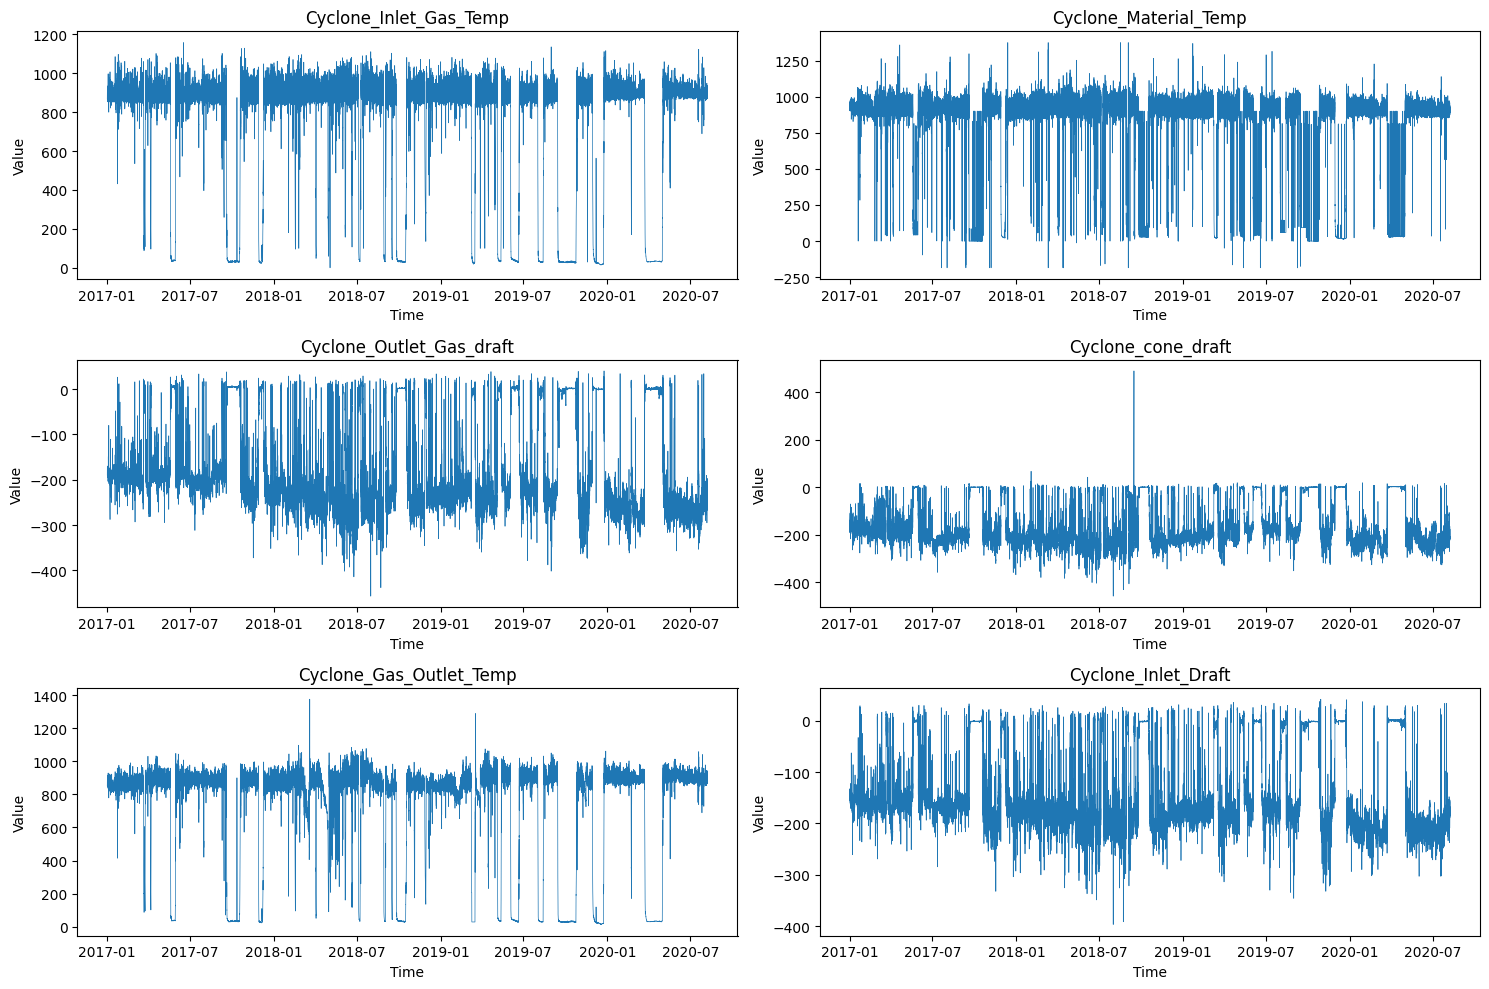

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(15, 10))

for ax, col in zip(axes.flat, sensor_cols):
    ax.plot(df["time"], df[col], linewidth=0.5)
    ax.set_title(col)
    ax.set_xlabel("Time")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.show()

In [12]:
X = df[sensor_cols]

In [13]:
model = IsolationForest(
    n_estimators=100,
    contamination=0.01,
    random_state=42
)

model.fit(X)

,n_estimators,100
,max_samples,'auto'
,contamination,0.01
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [14]:
df["anomaly"] = model.predict(X)

df["anomaly_score"] = model.decision_function(X)

In [15]:
total = len(df)
anomalies = (df["anomaly"] == -1).sum()
percentage = anomalies / total * 100

print("Total records:", total)
print("Anomalies:", anomalies)
print("Anomaly percentage:", percentage)

Total records: 377719
Anomalies: 3778
Anomaly percentage: 1.0002144451298454


In [16]:
anomalies_df = df[df["anomaly"] == -1].copy()

anomalies_df = anomalies_df.sort_values("time")

print("Number of anomalous observations:", len(anomalies_df))

Number of anomalous observations: 3778


In [17]:
anomalies_df["time_gap"] = anomalies_df["time"].diff()

In [18]:
anomalies_df["new_event"] = (
    anomalies_df["time_gap"] > pd.Timedelta(minutes=10)
).cumsum()

In [19]:
abnormal_periods = anomalies_df.groupby("new_event").agg(
    start_time=("time", "min"),
    end_time=("time", "max"),
    anomaly_count=("time", "count")
).reset_index(drop=True)

abnormal_periods["duration"] = (
    abnormal_periods["end_time"] - abnormal_periods["start_time"]
)

print(abnormal_periods)

             start_time            end_time  anomaly_count        duration
0   2017-01-23 03:10:00 2017-01-23 03:10:00              1 0 days 00:00:00
1   2017-01-23 03:30:00 2017-01-23 03:35:00              2 0 days 00:05:00
2   2017-01-23 04:05:00 2017-01-23 04:05:00              1 0 days 00:00:00
3   2017-01-23 04:25:00 2017-01-23 04:45:00              4 0 days 00:20:00
4   2017-01-23 05:15:00 2017-01-23 05:15:00              1 0 days 00:00:00
..                  ...                 ...            ...             ...
478 2020-07-26 09:25:00 2020-07-26 09:25:00              1 0 days 00:00:00
479 2020-07-26 10:20:00 2020-07-26 10:35:00              4 0 days 00:15:00
480 2020-07-26 10:50:00 2020-07-26 11:35:00             10 0 days 00:45:00
481 2020-07-30 10:05:00 2020-07-30 10:45:00              6 0 days 00:40:00
482 2020-07-30 11:10:00 2020-07-30 11:35:00              4 0 days 00:25:00

[483 rows x 4 columns]


In [20]:
print(
    abnormal_periods
    .sort_values("duration", ascending=False)
    .head(20)
)

             start_time            end_time  anomaly_count        duration
370 2019-08-02 10:25:00 2019-08-03 01:25:00            181 0 days 15:00:00
96  2017-11-28 18:20:00 2017-11-29 08:40:00            173 0 days 14:20:00
33  2017-05-19 20:10:00 2017-05-20 09:00:00            155 0 days 12:50:00
199 2018-07-05 08:20:00 2018-07-05 20:15:00            144 0 days 11:55:00
352 2019-06-03 16:10:00 2019-06-04 00:45:00            104 0 days 08:35:00
159 2018-04-30 01:25:00 2018-04-30 09:40:00             97 0 days 08:15:00
386 2019-09-17 00:55:00 2019-09-17 08:15:00             89 0 days 07:20:00
229 2018-08-29 17:45:00 2018-08-30 00:20:00             80 0 days 06:35:00
388 2019-10-02 03:40:00 2019-10-02 10:10:00             79 0 days 06:30:00
250 2018-09-26 08:20:00 2018-09-26 14:40:00             76 0 days 06:20:00
392 2019-10-24 22:05:00 2019-10-25 03:40:00             67 0 days 05:35:00
110 2018-02-01 17:55:00 2018-02-01 23:20:00             64 0 days 05:25:00
453 2020-03-22 20:50:00 2

In [21]:
# Save all anomaly results
df.to_csv("../results/anomaly_results.csv", index=False)

# Save abnormal periods
abnormal_periods.to_csv("../results/abnormal_periods.csv", index=False)

print("Results saved successfully.")

Results saved successfully.


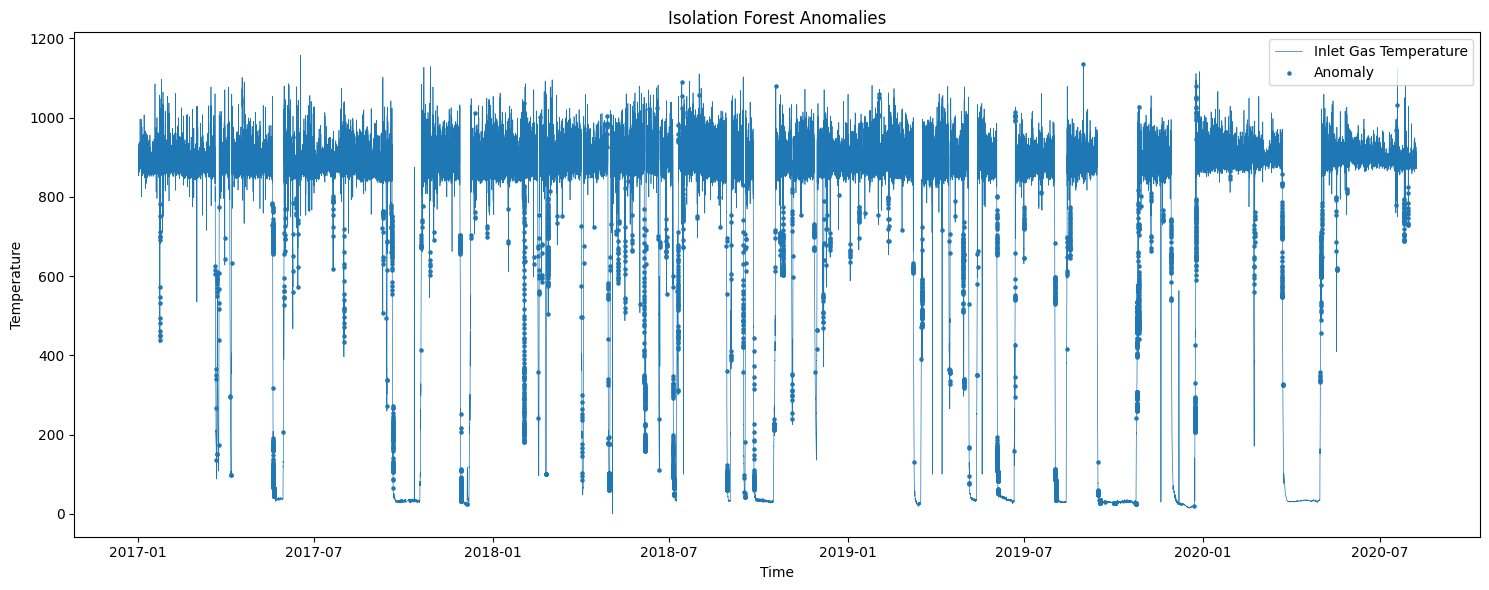

In [22]:
plt.figure(figsize=(15, 6))

plt.plot(
    df["time"],
    df["Cyclone_Inlet_Gas_Temp"],
    linewidth=0.5,
    label="Inlet Gas Temperature"
)

anomaly_points = df[df["anomaly"] == -1]

plt.scatter(
    anomaly_points["time"],
    anomaly_points["Cyclone_Inlet_Gas_Temp"],
    s=5,
    label="Anomaly"
)

plt.xlabel("Time")
plt.ylabel("Temperature")
plt.title("Isolation Forest Anomalies")
plt.legend()
plt.tight_layout()
plt.show()

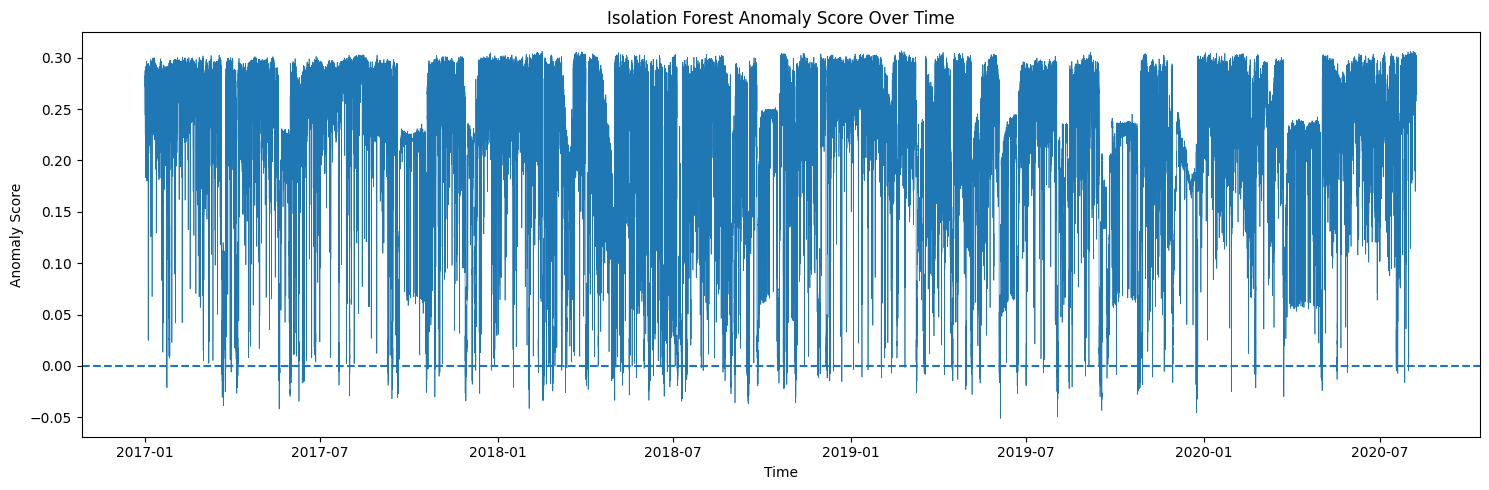

In [23]:
plt.figure(figsize=(15, 5))

plt.plot(
    df["time"],
    df["anomaly_score"],
    linewidth=0.5
)

plt.axhline(0, linestyle="--")

plt.xlabel("Time")
plt.ylabel("Anomaly Score")
plt.title("Isolation Forest Anomaly Score Over Time")

plt.tight_layout()
plt.show()

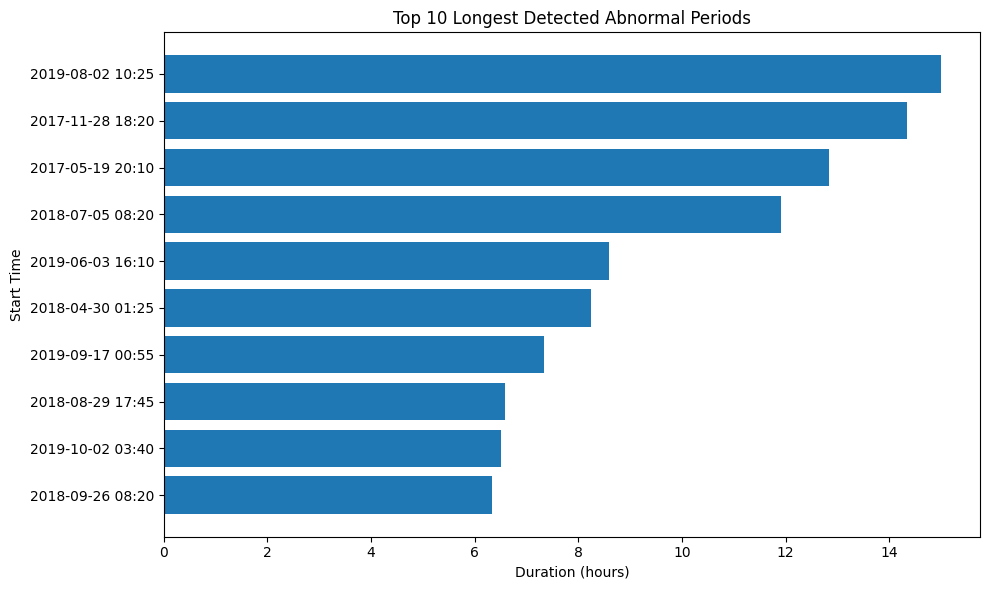

In [24]:
top_periods = (
    abnormal_periods
    .sort_values("duration", ascending=False)
    .head(10)
    .copy()
)

top_periods["duration_hours"] = (
    top_periods["duration"].dt.total_seconds() / 3600
)

plt.figure(figsize=(10, 6))

plt.barh(
    range(len(top_periods)),
    top_periods["duration_hours"]
)

plt.yticks(
    range(len(top_periods)),
    top_periods["start_time"].dt.strftime("%Y-%m-%d %H:%M")
)

plt.xlabel("Duration (hours)")
plt.ylabel("Start Time")
plt.title("Top 10 Longest Detected Abnormal Periods")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [25]:
plt.tight_layout()
plt.savefig("../plots/anomaly_score.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [26]:
plt.tight_layout()
plt.savefig("../plots/eda_correlation.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [27]:
plt.tight_layout()
plt.savefig("../plots/abnormal_periods.png", dpi=300, bbox_inches="tight")
plt.show()

<Figure size 640x480 with 0 Axes>

In [28]:
abnormal_periods.sort_values(
    "duration",
    ascending=False
).head(10)

,start_time,end_time,anomaly_count,duration
370,2019-08-02 10:25:00,2019-08-03 01:25:00,181,0 days 15:00:00
96,2017-11-28 18:20:00,2017-11-29 08:40:00,173,0 days 14:20:00
33,2017-05-19 20:10:00,2017-05-20 09:00:00,155,0 days 12:50:00
199,2018-07-05 08:20:00,2018-07-05 20:15:00,144,0 days 11:55:00
352,2019-06-03 16:10:00,2019-06-04 00:45:00,104,0 days 08:35:00
159,2018-04-30 01:25:00,2018-04-30 09:40:00,97,0 days 08:15:00
386,2019-09-17 00:55:00,2019-09-17 08:15:00,89,0 days 07:20:00
229,2018-08-29 17:45:00,2018-08-30 00:20:00,80,0 days 06:35:00
388,2019-10-02 03:40:00,2019-10-02 10:10:00,79,0 days 06:30:00
250,2018-09-26 08:20:00,2018-09-26 14:40:00,76,0 days 06:20:00
